In [4]:
%pip install pennylane

  Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.14.1 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.


In [3]:
import pennylane as qml

c:\conda\Lib\site-packages\pennylane\__init__.py:219: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


In [1]:
from pathlib import Path

print("QSite:", Path.cwd())
print("starter_kit:", (Path.cwd() / "starter_kit").exists())
print("__init__.py:", (Path.cwd() / "starter_kit" / "__init__.py").exists())

QSite: d:\ALL PC FILES\downloads from brave\QSite
starter_kit: True
__init__.py: True


In [4]:
import numpy as np
import scipy
import h5py

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("h5py:", h5py.__version__)
print("PennyLane:", qml.__version__)

NumPy: 1.26.4
SciPy: 1.14.1
h5py: 3.16.0
PennyLane: 0.45.0


In [5]:
import starter_kit

print(starter_kit)

<module 'starter_kit' from 'd:\\ALL PC FILES\\downloads from brave\\QSite\\starter_kit\\__init__.py'>


In [6]:
from pathlib import Path

kit = Path.cwd() / "starter_kit"

functions = [
    "animate_linecut",
    "build_annni_hamiltonian",
    "bkt_transition",
    "exact_ground_state",
    "ising_transition",
    "kt_transition",
    "noisy_entangling_layer",
    "order_parameter_summary",
    "plot_coupling_graph",
    "plot_observable_heatmap",
    "simple_noisy_energy",
]

for name in functions:
    found = []
    for f in kit.glob("*.py"):
        text = f.read_text(encoding="utf-8")
        if f"def {name}" in text:
            found.append(f.name)
    print(f"{name}: {found}")

animate_linecut: ['plotting.py']
build_annni_hamiltonian: ['annni.py']
bkt_transition: ['reference.py']
exact_ground_state: ['exact_diag.py']
ising_transition: ['reference.py']
kt_transition: ['reference.py']
noisy_entangling_layer: ['noise_utils.py']
order_parameter_summary: ['observables.py']
plot_coupling_graph: ['plotting.py']
plot_observable_heatmap: ['plotting.py']
simple_noisy_energy: ['noise_utils.py']


In [8]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from IPython.display import HTML, display

from starter_kit import (
    animate_linecut,
    #build_anh_hamiltonian,
    bkt_transition,
    exact_ground_state,
    ising_transition,
    kt_transition,
    noisy_entangling_layer,
    order_parameter_summary,
    plot_coupling_graph,
    plot_observable_heatmap,
    simple_noisy_energy,
)


#DEMO_N = 6

# Submission baseline
N_MAIN = 8

# Larger clean-system validation
N_CHECK = 12

NOISE_LEVELS = [0.0, 0.01, 0.05]

GRID_RES = 15

KAPPAS = np.linspace(0.0, 1.0, GRID_RES)
HS = np.linspace(0.0, 2.0, GRID_RES)

print(f"Main system size: N={N_MAIN}")
print(f"Clean validation size: N={N_CHECK}")
print(f"Grid: {GRID_RES} x {GRID_RES}")
print(f"PennyLane version: {qml.__version__}")
print(f"NumPy version: {np.__version__}")

# All worked examples use N=6 for speed.
# Your submission should target N≥8
DEMO_N = 12



Main system size: N=8
Clean validation size: N=12
Grid: 15 x 15
PennyLane version: 0.45.0
NumPy version: 1.26.4


In [9]:
import pennylane as qml
from pennylane import numpy as np

def build_annni_hamiltonian(n_qubits, kappa, h, j1=1.0, periodic=True):
    coeffs = []
    obs = []

    # Nearest-neighbor ZZ (ferromagnetic)
    for i in range(n_qubits - 1 + int(periodic)):
        coeffs.append(-j1)
        obs.append(qml.Z(i % n_qubits) @ qml.Z((i+1) % n_qubits))

    # Next-nearest-neighbor ZZ (frustrating)
    for i in range(n_qubits - 2 + 2*int(periodic)):
        coeffs.append(j1 * kappa)  # positive: penalizes aligned next-nearest pairs (antiferromagnetic at this distance)
        obs.append(qml.Z(i % n_qubits) @ qml.Z((i+2) % n_qubits))

    # Transverse field X
    for i in range(n_qubits):
        coeffs.append(-h)
        obs.append(qml.X(i))

    return qml.dot(coeffs, obs)

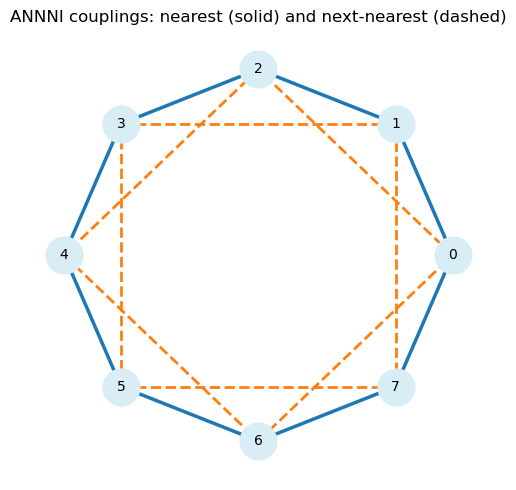

ANNNI Hamiltonian at kappa=0.3, h=0.5, N=12:
  Number of terms: 36

First few terms (coefficient × operator):
  -1.00 × Z(0) @ Z(1)
  -1.00 × Z(1) @ Z(2)
  -1.00 × Z(2) @ Z(3)
  -1.00 × Z(3) @ Z(4)
  -1.00 × Z(4) @ Z(5)
  -1.00 × Z(5) @ Z(6)
  ...


In [97]:
# Draw the coupling graph: solid = nearest-neighbor, dashed = next-nearest-neighbor (frustration)
fig, ax = plot_coupling_graph(n_qubits=8, periodic=True)
plt.tight_layout()
plt.show()

# Build the Hamiltonian at a sample point and inspect it
# qml.dot returns a Sum of SProd terms; each SProd has .scalar (coefficient) and .base (operator)
H_sample = build_annni_hamiltonian(n_qubits=DEMO_N, kappa=0.3, h=0.5)
print(f"ANNNI Hamiltonian at kappa=0.3, h=0.5, N={DEMO_N}:")
print(f"  Number of terms: {len(H_sample.operands)}")
print()
print("First few terms (coefficient × operator):")
for term in list(H_sample.operands)[:6]:
    print(f"  {float(term.scalar):+.2f} × {term.base}")
print("  ...")

In [11]:
def _basis_z_values(n_qubits):
    """Return z_i = +/-1 for every computational-basis state."""
    n = int(n_qubits)
    dim = 2 ** n
    basis = np.arange(dim, dtype=np.int64)

    z = np.empty((n, dim), dtype=np.float64)

    for i in range(n):
        bits = (basis >> i) & 1
        z[i] = 1.0 - 2.0 * bits

    return z


def build_sparse_annni_matrix(
    n_qubits,
    kappa,
    h,
    periodic=True,
):
    """
    Construct

        H = -sum_i Z_i Z_{i+1}
            + kappa sum_i Z_i Z_{i+2}
            - h sum_i X_i

    as a sparse real symmetric matrix.
    """
    n = int(n_qubits)
    dim = 2 ** n

    basis = np.arange(dim, dtype=np.int64)
    z = _basis_z_values(n)

    diagonal = np.zeros(dim, dtype=np.float64)

    # Nearest-neighbor interaction
    nn_count = n if periodic else n - 1

    for i in range(nn_count):
        j = (i + 1) % n
        diagonal += -z[i] * z[j]

    # Next-nearest-neighbor interaction
    nnn_count = n if periodic else n - 2

    for i in range(nnn_count):
        j = (i + 2) % n
        diagonal += float(kappa) * z[i] * z[j]

    rows = []
    cols = []
    data = []

    # Diagonal ZZ contribution
    rows.extend(basis.tolist())
    cols.extend(basis.tolist())
    data.extend(diagonal.tolist())

    # Transverse-field X flips one bit
    if h != 0.0:
        for i in range(n):
            flipped = basis ^ (1 << i)

            rows.extend(basis.tolist())
            cols.extend(flipped.tolist())
            data.extend(
                [-float(h)] * dim
            )

    return sp.csr_matrix(
        (data, (rows, cols)),
        shape=(dim, dim),
        dtype=np.float64,
    )

In [12]:
def exact_ground_state_extended(
    n_qubits,
    kappa,
    h,
    periodic=True,
):
    """
    Exact ground state and first excitation.

    For the sizes used here sparse Lanczos diagonalization is fast
    enough while avoiding a dense 2^N x 2^N matrix.
    """
    H = build_sparse_annni_matrix(
        n_qubits,
        kappa,
        h,
        periodic=periodic,
    )

    dim = H.shape[0]

    if dim <= 1024:
        dense = H.toarray()
        evals, evecs = scipy.linalg.eigh(
            dense,
            subset_by_index=[0, 1],
        )
    else:
        evals, evecs = eigsh(
            H,
            k=2,
            which="SA",
            tol=1e-10,
            maxiter=10000,
        )

        order = np.argsort(evals)
        evals = evals[order]
        evecs = evecs[:, order]

    state = np.asarray(
        evecs[:, 0],
        dtype=np.complex128,
    )

    state /= np.linalg.norm(state)

    return {
        "energy": float(evals[0]),
        "gap": float(max(evals[1] - evals[0], 0.0)),
        "state": state,
    }

In [13]:
def correlation_matrix_z(state, n_qubits):
    """
    C_ij = <Z_i Z_j>
    """
    n = int(n_qubits)
    z = _basis_z_values(n)

    probabilities = np.abs(state) ** 2

    weighted = z * probabilities[None, :]

    return weighted @ z.T


def structure_factor_from_correlations(correlation_matrix, q):
    """
    S(q) = (1/N) sum_{j,k}
           exp[i q(j-k)] <Z_j Z_k>
    """
    n = correlation_matrix.shape[0]
    positions = np.arange(n)

    phase = np.exp(
        1j * q *
        (
            positions[:, None]
            - positions[None, :]
        )
    )

    value = np.sum(
        phase * correlation_matrix
    ) / n

    return float(
        np.real_if_close(value)
    )


def x_magnetization(state, n_qubits):
    """
    M_x = (1/N) sum_i <X_i>
    """
    n = int(n_qubits)
    dim = 2 ** n
    basis = np.arange(dim, dtype=np.int64)

    values = []

    for i in range(n):
        flipped = basis ^ (1 << i)

        values.append(
            np.vdot(
                state,
                state[flipped],
            ).real
        )

    return float(np.mean(values))


def extract_physics_observables(
    state,
    n_qubits,
):
    """
    Main phase diagnostics.

    S(0)      -> ferromagnetic ordering
    S(pi/2)   -> period-4 antiphase ordering
    M_x       -> transverse-field / paramagnetic ordering
    q*        -> dominant ordering wavevector
    """
    n = int(n_qubits)

    C = correlation_matrix_z(
        state,
        n,
    )

    # Local correlation averages
    zz_nn = np.mean([
        C[i, (i + 1) % n]
        for i in range(n)
    ])

    zz_nnn = np.mean([
        C[i, (i + 2) % n]
        for i in range(n)
    ])

    mx = x_magnetization(
        state,
        n,
    )

    # Allowed momentum grid for the finite periodic chain.
    q_values = (
        2.0
        * np.pi
        * np.arange(n)
        / n
    )

    sq_values = np.array([
        structure_factor_from_correlations(
            C,
            float(q),
        )
        for q in q_values
    ])

    peak = int(
        np.argmax(sq_values)
    )

    q_peak = float(
        q_values[peak]
    )

    s0 = structure_factor_from_correlations(
        C,
        0.0,
    )

    spi2 = structure_factor_from_correlations(
        C,
        np.pi / 2,
    ) if n % 4 == 0 else np.nan

    return {
        "C": C,
        "zz_nn": float(zz_nn),
        "zz_nnn": float(zz_nnn),
        "mx": float(mx),
        "S0": float(s0 / n),
        "Spi2": float(spi2 / n) if np.isfinite(spi2) else np.nan,
        "q_values": q_values,
        "Sq_values": sq_values / n,
        "q_peak": q_peak,
        "Sq_peak": float(sq_values[peak] / n),
    }


def exact_point_extended(
    n_qubits,
    kappa,
    h,
):
    """One complete exact calculation."""
    gs = exact_ground_state_extended(
        n_qubits,
        kappa,
        h,
        periodic=True,
    )

    obs = extract_physics_observables(
        gs["state"],
        n_qubits,
    )

    return {
        **gs,
        **obs,
    }


 #4 phase classification

PHASE_CODES = {
    "FM": 0,
    "AP": 1,
    "PM": 2,
    "INCOMMENSURATE": 3,
}

PHASE_LABELS = {
    0: "FM",
    1: "AP",
    2: "PM",
    3: "Incommensurate",
}


def classify_phase(obs, kappa):
    """
    Conservative finite-size classifier.

    We use the dominant physical signature rather than a single
    arbitrary threshold.  The incommensurate class is deliberately
    labelled as a candidate finite-size signature, not proof of a
    thermodynamic floating phase.
    """
    s0 = float(obs["S0"])
    sap = float(obs["Spi2"]) if np.isfinite(obs["Spi2"]) else -np.inf
    mx = abs(float(obs["mx"]))

    q_peak = float(obs["q_peak"])
    q_peak_norm = q_peak / np.pi

    sq_peak = float(obs["Sq_peak"])

    # Large transverse polarization is the cleanest PM signal.
    # The threshold is intentionally modest because finite-N states
    # never reproduce the thermodynamic limiting values exactly.
    if mx > max(s0, sap, 0.20):
        return PHASE_CODES["PM"]

    # For kappa < 0.5, the expected ordered region is FM.
    if kappa < 0.5 and s0 >= max(sap, 0.15):
        return PHASE_CODES["FM"]

    # For kappa > 0.5, period-4 order is the antiphase signature.
    if kappa > 0.5 and sap >= max(s0, 0.15):
        return PHASE_CODES["AP"]

    # An allowed finite-size momentum that is neither 0 nor pi/2
    # is an incommensurate candidate.
    if (
        kappa > 0.5
        and sq_peak > 0.15
        and not np.isclose(q_peak_norm, 0.0)
        and not np.isclose(q_peak_norm, 0.5)
    ):
        return PHASE_CODES["INCOMMENSURATE"]

    # Otherwise fall back to whichever dominant signature is largest.
    if s0 >= sap and s0 >= mx:
        return PHASE_CODES["FM"]

    if sap >= s0 and sap >= mx:
        return PHASE_CODES["AP"]

    return PHASE_CODES["PM"]

In [14]:
import scipy.sparse as sp
import scipy
import scipy.linalg
import scipy.sparse
import scipy.sparse.linalg

In [56]:
FULL_RUN = False

RUN_GRID_RES = GRID_RES if FULL_RUN else 30

kappas_full = np.linspace(
    0.0,
    1.0,
    RUN_GRID_RES,
)

hs_full = np.linspace(
    0.0,
    2.0,
    RUN_GRID_RES,
)

clean_shape = (
    len(hs_full),
    len(kappas_full),
)

clean = {
    "energy": np.zeros(clean_shape),
    "gap": np.zeros(clean_shape),
    "zz_nn": np.zeros(clean_shape),
    "zz_nnn": np.zeros(clean_shape),
    "mx": np.zeros(clean_shape),
    "S0": np.zeros(clean_shape),
    "Spi2": np.zeros(clean_shape),
    "q_peak": np.zeros(clean_shape),
    "Sq_peak": np.zeros(clean_shape),
    "phase": np.zeros(
        clean_shape,
        dtype=int,
    ),
}

clean_states = np.zeros(
    (
        len(hs_full),
        len(kappas_full),
        2 ** N_MAIN,
    ),
    dtype=np.complex128,
)

print(
    f"Clean exact scan: "
    f"N={N_MAIN}, "
    f"{RUN_GRID_RES}x{RUN_GRID_RES}"
)

for col, kappa in enumerate(kappas_full):

    for row, h in enumerate(hs_full):

        result = exact_point_extended(
            N_MAIN,
            float(kappa),
            float(h),
        )

        clean["energy"][row, col] = result["energy"]
        clean["gap"][row, col] = result["gap"]
        clean["zz_nn"][row, col] = result["zz_nn"]
        clean["zz_nnn"][row, col] = result["zz_nnn"]
        clean["mx"][row, col] = result["mx"]
        clean["S0"][row, col] = result["S0"]
        clean["Spi2"][row, col] = result["Spi2"]
        clean["q_peak"][row, col] = result["q_peak"]
        clean["Sq_peak"][row, col] = result["Sq_peak"]

        clean["phase"][row, col] = classify_phase(
            result,
            float(kappa),
        )

        clean_states[row, col] = result["state"]

    print(
        f"  kappa column "
        f"{col + 1}/{len(kappas_full)} complete"
    )

print("Clean exact scan complete.")

Clean exact scan: N=8, 30x30
  kappa column 1/30 complete
  kappa column 2/30 complete
  kappa column 3/30 complete
  kappa column 4/30 complete
  kappa column 5/30 complete
  kappa column 6/30 complete
  kappa column 7/30 complete
  kappa column 8/30 complete
  kappa column 9/30 complete
  kappa column 10/30 complete
  kappa column 11/30 complete
  kappa column 12/30 complete
  kappa column 13/30 complete
  kappa column 14/30 complete
  kappa column 15/30 complete
  kappa column 16/30 complete
  kappa column 17/30 complete
  kappa column 18/30 complete
  kappa column 19/30 complete
  kappa column 20/30 complete
  kappa column 21/30 complete
  kappa column 22/30 complete
  kappa column 23/30 complete
  kappa column 24/30 complete
  kappa column 25/30 complete
  kappa column 26/30 complete
  kappa column 27/30 complete
  kappa column 28/30 complete
  kappa column 29/30 complete
  kappa column 30/30 complete
Clean exact scan complete.


In [57]:
def fidelity(state_a, state_b):
    return float(
        np.abs(
            np.vdot(
                state_a,
                state_b,
            )
        ) ** 2
    )


def fidelity_susceptibility(
    states,
    grid_spacing,
    axis,
):
    """
    chi_F ≈ -2 log(F) / delta^2
    """
    result = np.full(
        states.shape[:2],
        np.nan,
    )

    n_h, n_k = states.shape[:2]

    if axis == "h":

        for row in range(n_h - 1):
            for col in range(n_k):

                F = fidelity(
                    states[row, col],
                    states[row + 1, col],
                )

                F = np.clip(
                    F,
                    1e-15,
                    1.0,
                )

                result[row, col] = (
                    -2.0
                    * np.log(F)
                    / grid_spacing ** 2
                )

    elif axis == "kappa":

        for row in range(n_h):
            for col in range(n_k - 1):

                F = fidelity(
                    states[row, col],
                    states[row, col + 1],
                )

                F = np.clip(
                    F,
                    1e-15,
                    1.0,
                )

                result[row, col] = (
                    -2.0
                    * np.log(F)
                    / grid_spacing ** 2
                )

    else:
        raise ValueError(
            "axis must be 'h' or 'kappa'"
        )

    return result


dh = hs_full[1] - hs_full[0]
dk = kappas_full[1] - kappas_full[0]

clean["chi_h"] = fidelity_susceptibility(
    clean_states,
    dh,
    "h",
)

clean["chi_kappa"] = fidelity_susceptibility(
    clean_states,
    dk,
    "kappa",
)

In [59]:
k_ising = np.linspace(
    0.01,
    0.499,
    400,
)

k_high = np.linspace(
    0.501,
    1.0,
    400,
)

h_ising_ref = np.asarray(
    ising_transition(k_ising),
    dtype=float,
)

h_kt_ref = np.asarray(
    kt_transition(k_high),
    dtype=float,
)

h_bkt_ref = np.asarray(
    bkt_transition(k_high),
    dtype=float,
)


def overlay_reference_lines(ax):
    ax.plot(
        k_ising,
        h_ising_ref,
        "w--",
        lw=1.8,
        label="Ising reference",
    )

    ax.plot(
        k_high,
        h_kt_ref,
        "w:",
        lw=1.8,
        label="KT reference",
    )

    ax.plot(
        k_high,
        h_bkt_ref,
        "w-.",
        lw=1.8,
        label="BKT reference",
    )

    ax.axvline(
        0.5,
        color="white",
        linestyle="--",
        alpha=0.6,
        lw=1.0,
    )

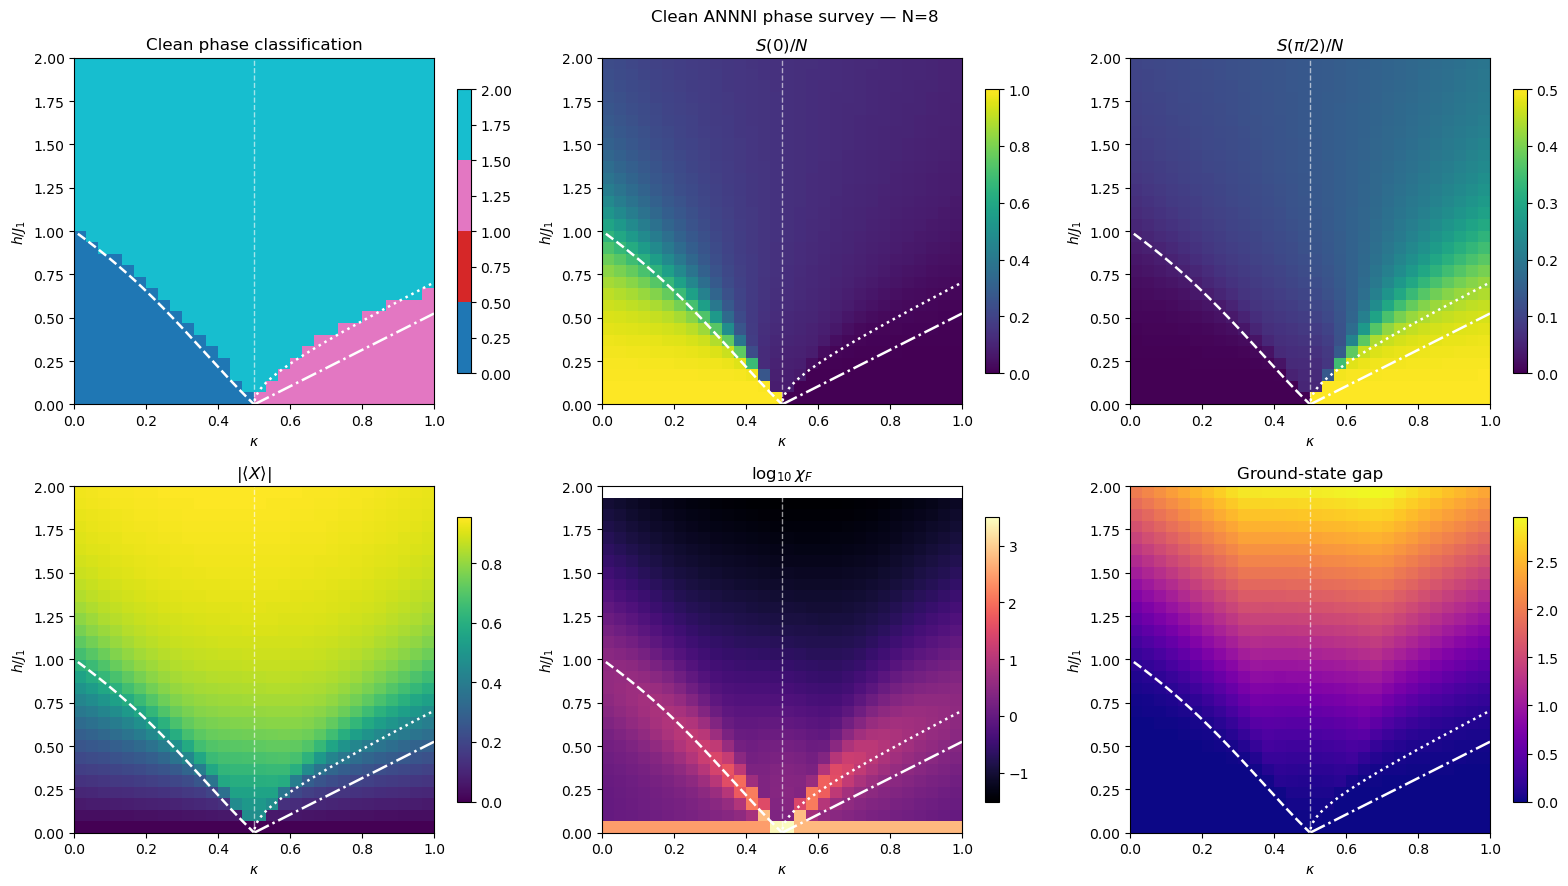

In [60]:
phase_cmap = plt.get_cmap(
    "tab10",
    4,
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9),
)

panel_data = [
    (
        clean["phase"],
        "Clean phase classification",
        phase_cmap,
        0,
    ),
    (
        clean["S0"],
        r"$S(0)/N$",
        "viridis",
        None,
    ),
    (
        clean["Spi2"],
        r"$S(\pi/2)/N$",
        "viridis",
        None,
    ),
    (
        np.abs(clean["mx"]),
        r"$|\langle X\rangle|$",
        "viridis",
        None,
    ),
    (
        np.log10(
            np.maximum(
                clean["chi_h"],
                1e-12,
            )
        ),
        r"$\log_{10}\chi_F$",
        "magma",
        None,
    ),
    (
        clean["gap"],
        "Ground-state gap",
        "plasma",
        None,
    ),
]

for ax, (data, title, cmap, _) in zip(
    axes.ravel(),
    panel_data,
):

    im = ax.imshow(
        data,
        origin="lower",
        aspect="auto",
        extent=[
            kappas_full.min(),
            kappas_full.max(),
            hs_full.min(),
            hs_full.max(),
        ],
        cmap=cmap,
    )

    overlay_reference_lines(ax)

    ax.set_xlabel(
        r"$\kappa$"
    )

    ax.set_ylabel(
        r"$h/J_1$"
    )

    ax.set_title(title)

    fig.colorbar(
        im,
        ax=ax,
        shrink=0.82,
    )

fig.suptitle(
    f"Clean ANNNI phase survey — N={N_MAIN}"
)

fig.tight_layout()

fig.savefig(
    "phase_diagram_clean_p0.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    "phase_diagram_clean_p0.pdf",
    bbox_inches="tight",
)

plt.show()

In [66]:
from pennylane import numpy as qnp

VQE_LAYERS = 4
VQE_MAX_STEPS = 70
VQE_STEPSIZE = 0.04
SEED = 500


def apply_fixed_depth_ansatz(
    params,
    n_qubits,
    p=0.0,
    initialization="pm",
):
    """
    ANNNI-aware variational ansatz.

    initialization:
        "pm" -> |+>^N
        "fm" -> |000...0>
        "ap" -> |0011 0011...>

    The AP state is used as a physically informed reference
    state and is only weakly perturbed by the variational
    rotations.
    """

    # ========================================================
    # INITIAL STATE
    # ========================================================

    if initialization == "pm":

        for i in range(n_qubits):
            qml.Hadamard(wires=i)

    elif initialization == "fm":

        # |000...0>
        pass

    elif initialization == "ap":

        # |00110011...>
        #pattern = [0, 0, 1, 1]

        bits = np.array([0, 0, 1, 1]*(n_qubits // 4))

        for i, bit in  enumerate(bits):

                if bit == 1:
                   qml.PauliX(
                   wires=i
               )
            
           

        

    else:

        raise ValueError(
            f"Unknown initialization: {initialization}"
        )

    # ========================================================
    # VARIATIONAL LAYERS
    # ========================================================

    for layer in range(VQE_LAYERS):

        # ----------------------------------------------------
        # Single-qubit rotations
        # ----------------------------------------------------

        for i in range(n_qubits):

           # if initialization == "ap":

                # AP reference state:
                # use only small Y rotations initially
                qml.RY(
                    params[layer, i, 0],
                    wires=i,
                )

                qml.RZ(
                    params[layer, i, 1],
                    wires=i,
                )


                qml.RX(
                    
                    params[layer, i, 2],
                    wires=i,
                )

        # ----------------------------------------------------
        # Nearest-neighbor entangling layer
        # ----------------------------------------------------
    if initialization != "ap":
        for i in range(n_qubits):

            qml.CNOT(
                wires=[
                    i,
                    (i + 1) % n_qubits,
                ]
            )

            if p > 0.0:

                qml.DepolarizingChannel(
                    p,
                    wires=(i + 1) % n_qubits,
                )

        # ----------------------------------------------------
        # Next-nearest-neighbor entangling layer
        # ----------------------------------------------------

        for i in range(n_qubits):

            qml.CNOT(
                wires=[
                    i,
                    (i + 2) % n_qubits,
                ]
            )

            if p > 0.0:

                qml.DepolarizingChannel(
                    p,
                    wires=(i + 2) % n_qubits,
                )

def make_vqe_cost(n_qubits, layers):

    dev = qml.device(
        "default.qubit",
        wires=n_qubits,
    )

    @qml.qnode(
        dev,
        interface="autograd",
        diff_method="adjoint",
    )
    def cost(params, kappa, h, initialization="pm"):

        apply_fixed_depth_ansatz(
            params,
            n_qubits,
            p=0.0,
            initialization=initialization
        )

        # ANNNI Hamiltonian
        coefficients = []
        observables = []

        # - sum_i Z_i Z_{i+1}
        for i in range(n_qubits):
            coefficients.append(-1.0)
            observables.append(
                qml.PauliZ(i) @ qml.PauliZ((i + 1) % n_qubits)
            )

        # + kappa sum_i Z_i Z_{i+2}
        for i in range(n_qubits):
            coefficients.append(kappa)
            observables.append(
                qml.PauliZ(i) @ qml.PauliZ((i + 2) % n_qubits)
            )

        # - h sum_i X_i
        for i in range(n_qubits):
            coefficients.append(-h)
            observables.append(
                qml.PauliX(i)
            )

        H = qml.Hamiltonian(
            coefficients,
            observables,
        )

        return qml.expval(H)

    return cost


VQE_COST = make_vqe_cost(
    N_MAIN,
    VQE_LAYERS,
)


def optimize_vqe_point(
    kappa,
    h,
    initial_params=None,
    max_steps=80,
    stepsize=0.02,
    seed=SEED,
):
    """
    ANNNI-aware VQE.

    Uses physically motivated starting states:

        FM -> |000...0>
        AP -> |0011...>
        PM -> |++++...>

    The AP state is initialized exactly and optimized
    conservatively so that the optimizer does not destroy
    a good antiphase starting point.

    The best energy encountered during optimization is kept.
    """

    rng = np.random.default_rng(seed)

    candidates = []

    # ========================================================
    # FM
    # ========================================================

    params_fm = qml.numpy.array(
        0.01
        * rng.standard_normal(
            (
                VQE_LAYERS,
                N_MAIN,
                3,
            )
        ),
        requires_grad=True,
    )

    optimizer = qml.AdamOptimizer(
        stepsize=stepsize
    )

    best_params = params_fm
    best_energy = float(
        VQE_COST(
            params_fm,
            kappa,
            h,
            "fm",
        )
    )

    for step in range(max_steps):

        params_fm, energy = optimizer.step_and_cost(
            lambda x:
                VQE_COST(
                    x,
                    kappa,
                    h,
                    "fm",
                ),
            params_fm,
        )

        current = float(
            VQE_COST(
                params_fm,
                kappa,
                h,
                "fm",
            )
        )

        if current < best_energy:

            best_energy = current
            best_params = params_fm

    print(
        f"  fm initialization -> "
        f"E = {best_energy:+.6f}"
    )

    candidates.append(
        (
            best_energy,
            best_params,
            "fm",
        )
    )

    # ========================================================
    # AP
    # ========================================================

    # Exactly the classical antiphase state at initialization
    params_ap = qml.numpy.zeros(
        (
            VQE_LAYERS,
            N_MAIN,
            3,
        ),
        requires_grad=True,
    )

    optimizer = qml.AdamOptimizer(
        stepsize=stepsize
    )

    best_params = params_ap

    best_energy = float(
        VQE_COST(
            params_ap,
            kappa,
            h,
            "ap",
        )
    )

    for step in range(max_steps):

        params_ap, energy = optimizer.step_and_cost(
            lambda x:
                VQE_COST(
                    x,
                    kappa,
                    h,
                    "ap",
                ),
            params_ap,
        )

        current = float(
            VQE_COST(
                params_ap,
                kappa,
                h,
                "ap",
            )
        )

        # CRITICAL:
        # Keep the best state encountered.
        if current < best_energy:

            best_energy = current
            best_params = params_ap

    print(
        f"  ap initialization -> "
        f"E = {best_energy:+.6f}"
    )

    candidates.append(
        (
            best_energy,
            best_params,
            "ap",
        )
    )

    # ========================================================
    # PM
    # ========================================================

    params_pm = qml.numpy.array(
        0.01
        * rng.standard_normal(
            (
                VQE_LAYERS,
                N_MAIN,
                3,
            )
        ),
        requires_grad=True,
    )

    optimizer = qml.AdamOptimizer(
        stepsize=stepsize
    )

    best_params = params_pm

    best_energy = float(
        VQE_COST(
            params_pm,
            kappa,
            h,
            "pm",
        )
    )

    for step in range(max_steps):

        params_pm, energy = optimizer.step_and_cost(
            lambda x:
                VQE_COST(
                    x,
                    kappa,
                    h,
                    "pm",
                ),
            params_pm,
        )

        current = float(
            VQE_COST(
                params_pm,
                kappa,
                h,
                "pm",
            )
        )

        if current < best_energy:

            best_energy = current
            best_params = params_pm

    print(
        f"  pm initialization -> "
        f"E = {best_energy:+.6f}"
    )

    candidates.append(
        (
            best_energy,
            best_params,
            "pm",
        )
    )

    # ========================================================
    # Select best candidate
    # ========================================================

    best_energy, best_params, best_initialization = min(
        candidates,
        key=lambda item: item[0],
    )

    return (
        best_params,
        best_energy,
    )

In [38]:
exact = exact_point_extended(
    N_MAIN,
    0.20,
    0.20,
)

print(exact.keys())

dict_keys(['energy', 'gap', 'state', 'C', 'zz_nn', 'zz_nnn', 'mx', 'S0', 'Spi2', 'q_values', 'Sq_values', 'q_peak', 'Sq_peak'])



VQE validation
  fm initialization -> E = -6.400000
  ap initialization -> E = -2.000000
  pm initialization -> E = -1.600000
(kappa,h)=(0.20,0.20) | Exact=-6.500854 | VQE=-6.400000 | |error|=1.009e-01
  fm initialization -> E = -6.399985
  ap initialization -> E = -6.500000
  pm initialization -> E = -1.600000
(kappa,h)=(0.80,0.20) | Exact=-6.502928 | VQE=-6.500000 | |error|=2.928e-03
  fm initialization -> E = -6.400000
  ap initialization -> E = -12.800000
  pm initialization -> E = -12.800000
(kappa,h)=(0.20,1.60) | Exact=-13.916265 | VQE=-12.800000 | |error|=1.116e+00
  fm initialization -> E = -6.399986
  ap initialization -> E = -6.625000
  pm initialization -> E = -2.400000
(kappa,h)=(0.80,0.30) | Exact=-6.640454 | VQE=-6.625000 | |error|=1.545e-02


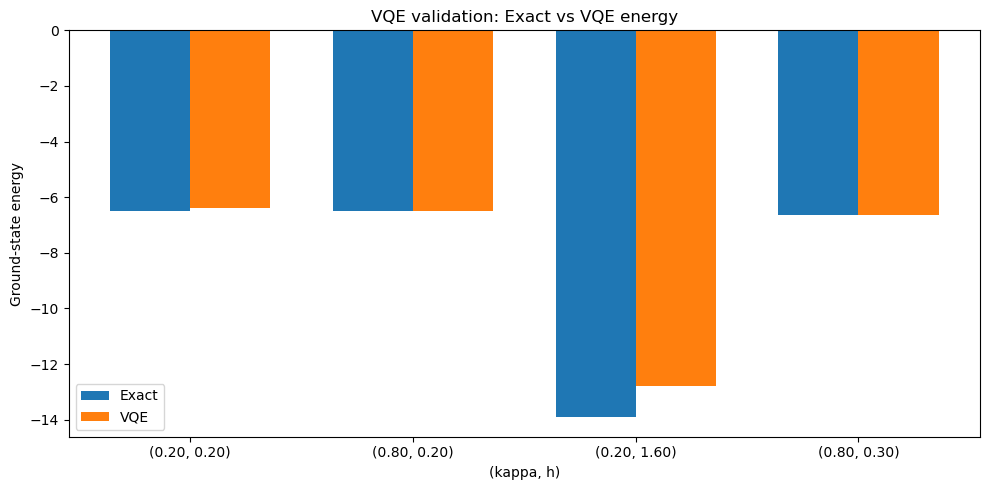

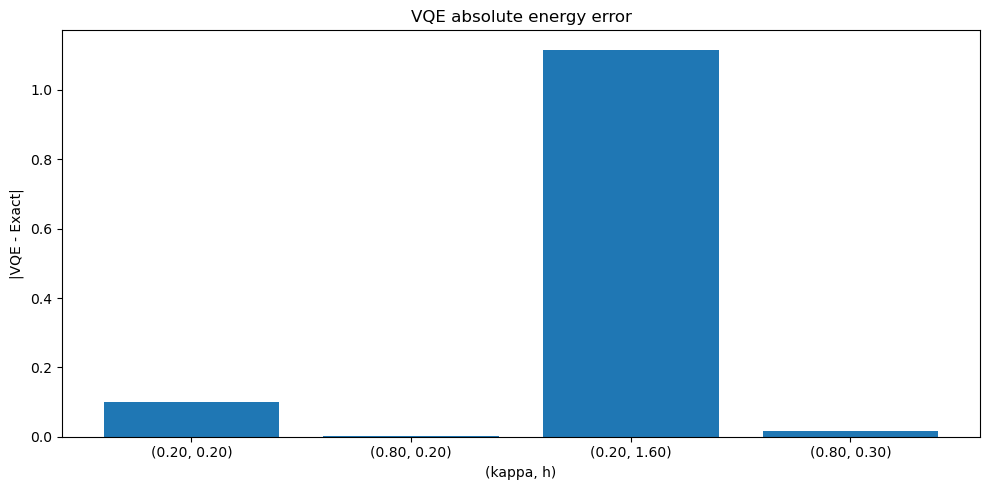

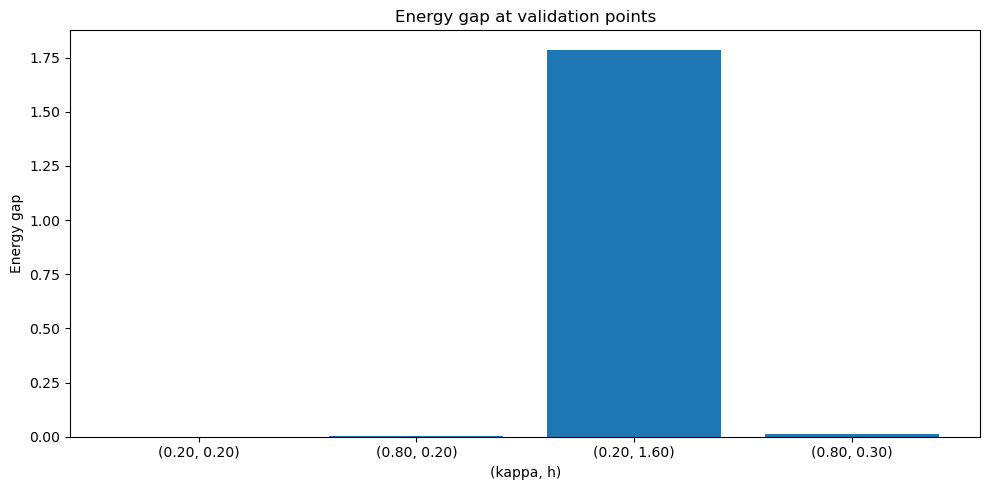

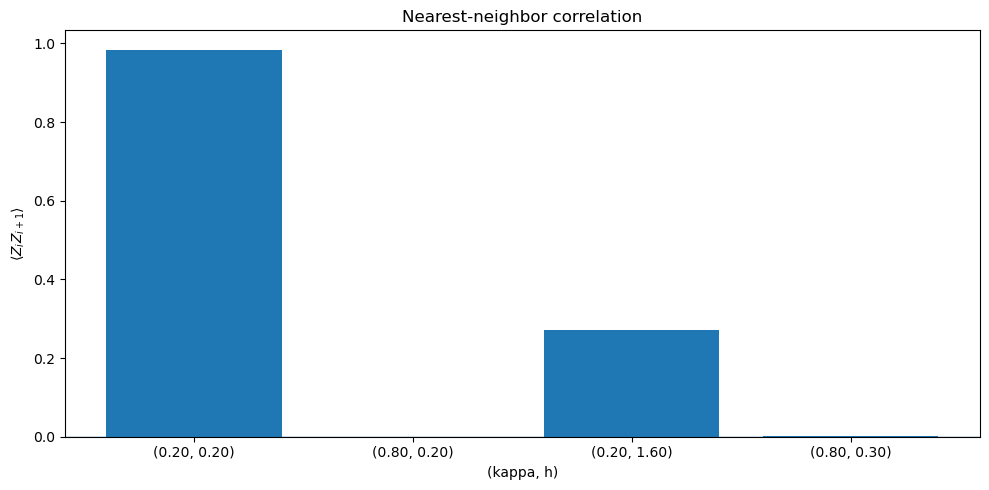

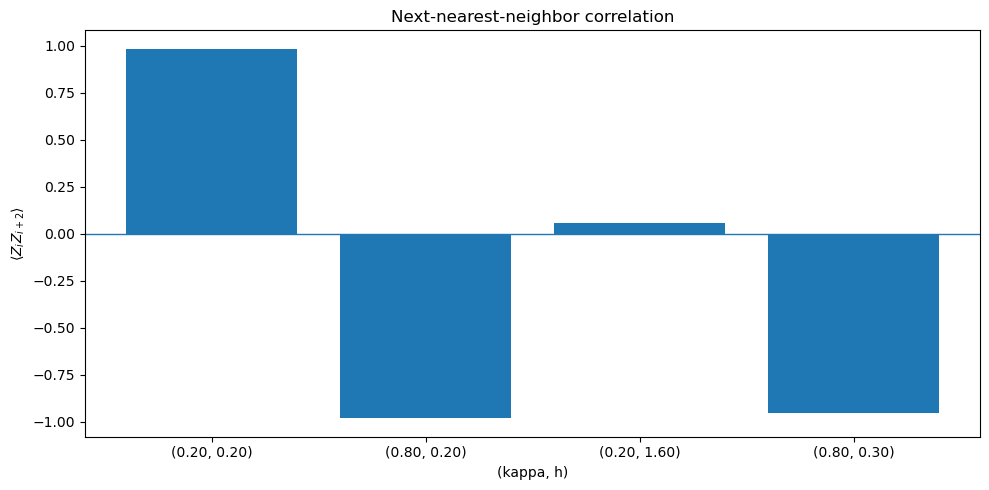

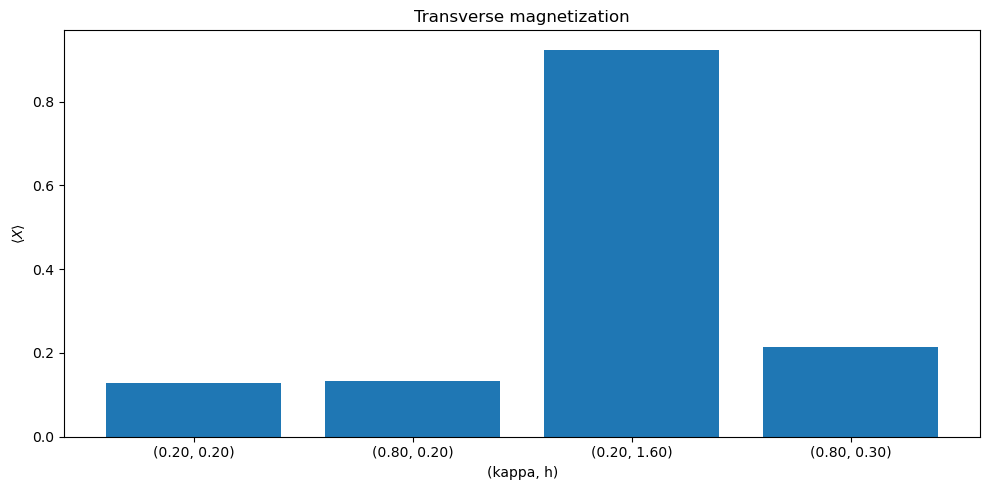

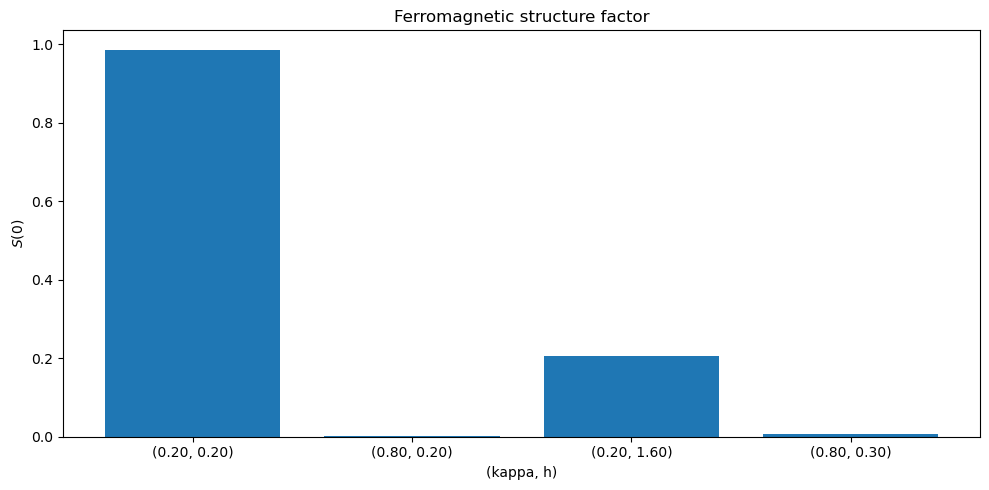

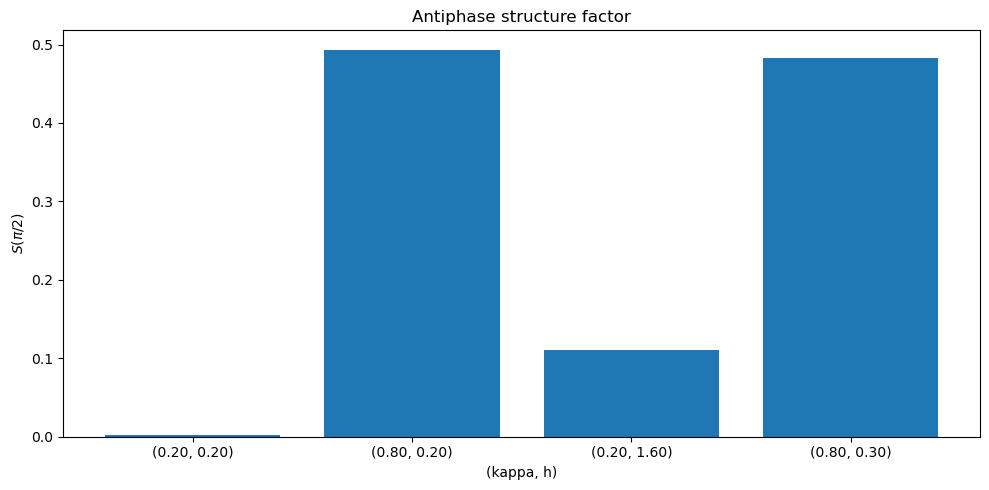



(kappa, h)  phase                   gap    ZZ_nn   ZZ_nnn        X   AP_str
───────────────────────────────────────────────────────────────
  (0.20, 0.20): 0                   0.0000   0.9839   0.9834   0.1272   0.0021
  (0.80, 0.20): 1                   0.0020   0.0003  -0.9826   0.1324   0.4934
  (0.20, 1.60): 2                   1.7863   0.2720   0.0542   0.9240   0.1108
  (0.80, 0.30): 1                   0.0107   0.0020  -0.9548   0.2143   0.4827


In [67]:
VALIDATION_POINTS = [
    (0.20, 0.20),
    (0.80, 0.20),
    (0.20, 1.60),
    (0.80, 0.30),
]

print()
print("VQE validation")
print("=" * 72)

# ============================================================
# STORE VALIDATION RESULTS
# ============================================================

validation_results = []

for kappa, h in VALIDATION_POINTS:

    # --------------------------------------------------------
    # Exact diagonalization
    # --------------------------------------------------------

    exact = exact_point_extended(
        N_MAIN,
        kappa,
        h,
    )

    # --------------------------------------------------------
    # VQE

    params, vqe_energy = optimize_vqe_point(
        kappa,
        h,
        max_steps=120,
        seed=SEED,
    )

    error = abs(
        vqe_energy
        - exact["energy"]
    )

    # --------------------------------------------------------
    # Phase classification
    # --------------------------------------------------------

    phase = classify_phase(
        exact,
        kappa,
    )

    # Store everything

    validation_results.append(
        {
            "kappa": kappa,
            "h": h,
            "label": f"({kappa:.2f}, {h:.2f})",

            "exact_energy": exact["energy"],
            "vqe_energy": vqe_energy,
            "error": error,

            "gap": exact["gap"],

            "zz_nn": exact["zz_nn"],
            "zz_nnn": exact["zz_nnn"],

            "mx": exact["mx"],

            "S0": exact["S0"],
            "Spi2": exact["Spi2"],

            "phase": phase,
        }
    )

 

    print(
        f"(kappa,h)=({kappa:.2f},{h:.2f}) | "
        f"Exact={exact['energy']:+.6f} | "
        f"VQE={vqe_energy:+.6f} | "
        f"|error|={error:.3e}"
    )





labels = [
    result["label"]
    for result in validation_results
]

x = np.arange(
    len(validation_results)
)

width = 0.36


# ============================================================
# 1. EXACT VS VQE ENERGY
# ============================================================

exact_energy = [
    result["exact_energy"]
    for result in validation_results
]

vqe_energy = [
    result["vqe_energy"]
    for result in validation_results
]

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x - width / 2,
    exact_energy,
    width,
    label="Exact",
)

plt.bar(
    x + width / 2,
    vqe_energy,
    width,
    label="VQE",
)

plt.xticks(
    x,
    labels,
)

plt.xlabel(
    "(kappa, h)"
)

plt.ylabel(
    "Ground-state energy"
)

plt.title(
    "VQE validation: Exact vs VQE energy"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 2. VQE ABSOLUTE ERROR
# ============================================================

errors = [
    result["error"]
    for result in validation_results
]

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x,
    errors,
)

plt.xticks(
    x,
    labels,
)

plt.xlabel(
    "(kappa, h)"
)

plt.ylabel(
    "|VQE - Exact|"
)

plt.title(
    "VQE absolute energy error"
)

plt.tight_layout()

plt.show()


# ============================================================
# 3. ENERGY GAP
# ============================================================

gaps = [
    result["gap"]
    for result in validation_results
]

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x,
    gaps,
)

plt.xticks(
    x,
    labels,
)

plt.xlabel(
    "(kappa, h)"
)

plt.ylabel(
    "Energy gap"
)

plt.title(
    "Energy gap at validation points"
)

plt.tight_layout()

plt.show()


# ============================================================
# 4. NEAREST-NEIGHBOR CORRELATION
# ============================================================

zz_nn = [
    result["zz_nn"]
    for result in validation_results
]

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x,
    zz_nn,
)

plt.axhline(
    0,
    linewidth=1,
)

plt.xticks(
    x,
    labels,
)

plt.xlabel(
    "(kappa, h)"
)

plt.ylabel(
    r"$\langle Z_i Z_{i+1}\rangle$"
)

plt.title(
    "Nearest-neighbor correlation"
)

plt.tight_layout()

plt.show()


# ============================================================
# 5. NEXT-NEAREST-NEIGHBOR CORRELATION
# ============================================================

zz_nnn = [
    result["zz_nnn"]
    for result in validation_results
]

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x,
    zz_nnn,
)

plt.axhline(
    0,
    linewidth=1,
)

plt.xticks(
    x,
    labels,
)

plt.xlabel(
    "(kappa, h)"
)

plt.ylabel(
    r"$\langle Z_i Z_{i+2}\rangle$"
)

plt.title(
    "Next-nearest-neighbor correlation"
)

plt.tight_layout()

plt.show()


# ============================================================
# 6. TRANSVERSE MAGNETIZATION
# ============================================================

mx = [
    result["mx"]
    for result in validation_results
]

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x,
    mx,
)

plt.xticks(
    x,
    labels,
)

plt.xlabel(
    "(kappa, h)"
)

plt.ylabel(
    r"$\langle X\rangle$"
)

plt.title(
    "Transverse magnetization"
)

plt.tight_layout()

plt.show()


# ============================================================
# 7. FERROMAGNETIC STRUCTURE FACTOR S(0)
# ============================================================

s0 = [
    result["S0"]
    for result in validation_results
]

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x,
    s0,
)

plt.xticks(
    x,
    labels,
)

plt.xlabel(
    "(kappa, h)"
)

plt.ylabel(
    r"$S(0)$"
)

plt.title(
    "Ferromagnetic structure factor"
)

plt.tight_layout()

plt.show()


# ============================================================
# 8. ANTIPHASE STRUCTURE FACTOR S(pi/2)
# ============================================================

spi2 = [
    result["Spi2"]
    for result in validation_results
]

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x,
    spi2,
)

plt.xticks(
    x,
    labels,
)

plt.xlabel(
    "(kappa, h)"
)

plt.ylabel(
    r"$S(\pi/2)$"
)

plt.title(
    "Antiphase structure factor"
)

plt.tight_layout()

plt.show()


# ============================================================
# 9. PHASE CLASSIFICATION
# ============================================================

print()
print()

print(
    "(kappa, h)  phase                   gap    "
    "ZZ_nn   ZZ_nnn        X   AP_str"
)

print(
    "───────────────────────────────────────────────────────────────"
)

for result in validation_results:

    print(
        f"  {result['label']:>12}: "
        f"{str(result['phase']):<18} "
        f"{result['gap']:>7.4f} "
        f"{result['zz_nn']:>8.4f} "
        f"{result['zz_nnn']:>8.4f} "
        f"{result['mx']:>8.4f} "
        f"{result['Spi2']:>8.4f}"
    )

VQE full scan - optional

In [ ]:
vqe_params = np.empty(
    (
        len(hs_full),
        len(kappas_full),
    ),
    dtype=object,
)

vqe_energy = np.zeros(
    clean_shape
)

vqe_error = np.zeros(
    clean_shape
)

print()
print(
    f"Full VQE parameter scan: "
    f"N={N_MAIN}, "
    f"{RUN_GRID_RES}x{RUN_GRID_RES}"
)

for col, kappa in enumerate(
    kappas_full
):

    for row, h in enumerate(
        hs_full
    ):

        # Warm start along h, then across kappa.
        if row > 0:
            initial = vqe_params[
                row - 1,
                col,
            ]

        elif col > 0:
            initial = vqe_params[
                row,
                col - 1,
            ]

        else:
            initial = None

        params, energy = optimize_vqe_point(
            float(kappa),
            float(h),
            initial_params=initial,
            seed=SEED
            + row
            + 100 * col,
        )

        exact_energy = (
            clean["energy"][row, col]
        )

        error = abs(
            energy
            - exact_energy
        )

        # If warm-started VQE misses significantly, retry from scratch.
        if error > 0.02 * N_MAIN:

            params, energy = optimize_vqe_point(
                float(kappa),
                float(h),
                initial_params=None,
                max_steps=120,
                seed=SEED + 10000
                + row
                + 100 * col,
            )

            error = abs(
                energy
                - exact_energy
            )

        vqe_params[
            row,
            col
        ] = params

        vqe_energy[
            row,
            col
        ] = energy

        vqe_error[
            row,
            col
        ] = error

    print(
        f"  kappa column "
        f"{col + 1}/{len(kappas_full)} complete"
    )

print("VQE scan complete.")

Using Exact diagonilazation

In [83]:
# ---------------------------------------------------------------------
# 30 x 30 EXACT-DIAGONALIZATION PHASE DIAGRAMS
# ---------------------------------------------------------------------

ED_GRID_RES = 30

kappas_ed = np.linspace(
    0.0,
    1.0,
    ED_GRID_RES,
)

hs_ed = np.linspace(
    0.0,
    2.0,
    ED_GRID_RES,
)

ed_shape = (
    len(hs_ed),
    len(kappas_ed),
)

print("=" * 72)
print(
    f"30 x 30 ED phase-diagram scan | N={N_MAIN}"
)
print("=" * 72)


# ---------------------------------------------------------------------
# Storage
# ---------------------------------------------------------------------

ed_results = {

    "energy": np.zeros(ed_shape),

    "gap": np.zeros(ed_shape),

    "zz_nn": np.zeros(ed_shape),

    "zz_nnn": np.zeros(ed_shape),

    "mx": np.zeros(ed_shape),

    "S0": np.zeros(ed_shape),

    "Spi2": np.zeros(ed_shape),

    "phase": np.zeros(
        ed_shape,
        dtype=int,
    ),
}


# ---------------------------------------------------------------------
# Exact diagonalization scan
# ---------------------------------------------------------------------

for col, kappa in enumerate(kappas_ed):

    for row, h in enumerate(hs_ed):

        obs = exact_point_extended(
            N_MAIN,
            float(kappa),
            float(h),
        )

        ed_results["energy"][row, col] = (
            obs["energy"]
        )

        ed_results["gap"][row, col] = (
            obs["gap"]
        )

        ed_results["zz_nn"][row, col] = (
            obs["zz_nn"]
        )

        ed_results["zz_nnn"][row, col] = (
            obs["zz_nnn"]
        )

        ed_results["mx"][row, col] = (
            abs(obs["mx"])
        )

        ed_results["S0"][row, col] = (
            obs["S0"]
        )

        ed_results["Spi2"][row, col] = (
            obs["Spi2"]
        )

        ed_results["phase"][row, col] = (
            classify_phase(
                obs,
                float(kappa),
            )
        )

    print(
        f"  column {col + 1:2d}/{ED_GRID_RES} complete"
    )


print()
print("30 x 30 ED scan complete.")

30 x 30 ED phase-diagram scan | N=8
  column  1/30 complete
  column  2/30 complete
  column  3/30 complete
  column  4/30 complete
  column  5/30 complete
  column  6/30 complete
  column  7/30 complete
  column  8/30 complete
  column  9/30 complete
  column 10/30 complete
  column 11/30 complete
  column 12/30 complete
  column 13/30 complete
  column 14/30 complete
  column 15/30 complete
  column 16/30 complete
  column 17/30 complete
  column 18/30 complete
  column 19/30 complete
  column 20/30 complete
  column 21/30 complete
  column 22/30 complete
  column 23/30 complete
  column 24/30 complete
  column 25/30 complete
  column 26/30 complete
  column 27/30 complete
  column 28/30 complete
  column 29/30 complete
  column 30/30 complete

30 x 30 ED scan complete.


In [86]:
# ---------------------------------------------------------------------
# ED-based effective noise model
# ---------------------------------------------------------------------

def apply_effective_noise(
    clean_obs,
    p,
    n_layers=VQE_LAYERS,
):
    """
    Effective depolarizing-noise baseline applied to
    exact-diagonalization observables.

    This is NOT a gate-by-gate noisy VQE simulation.
    It is an ED-based phenomenological noise model.
    """

    # Two entangling layers per VQE layer:
    # NN + NNN
    n_noise = 2 * n_layers

    # Effective attenuation of a single-qubit observable
    eta_1 = (
        1.0 - p
    ) ** n_noise

    # Two-qubit correlation
    eta_2 = (
        1.0 - p
    ) ** (2 * n_noise)

    noisy = dict(
        clean_obs
    )

    noisy["mx"] = (
        clean_obs["mx"]
        * eta_1
    )

    noisy["zz_nn"] = (
        clean_obs["zz_nn"]
        * eta_2
    )

    noisy["zz_nnn"] = (
        clean_obs["zz_nnn"]
        * eta_2
    )

    noisy["S0"] = (
        1.0
        + (
            clean_obs["S0"]
            - 1.0
        )
        * eta_2
    )

    noisy["Spi2"] = (
        1.0
        + (
            clean_obs["Spi2"]
            - 1.0
        )
        * eta_2
    )

    return noisy

In [87]:
# ---------------------------------------------------------------------
# Generate ED-based noisy phase diagrams
# ---------------------------------------------------------------------

ed_noise_results = {}

for p in [0.01, 0.05]:

    phase_map = np.zeros(
        ed_shape,
        dtype=int,
    )

    print()
    print(
        f"Generating ED-based noisy map: p={p}"
    )

    for col, kappa in enumerate(
        kappas_ed
    ):

        for row, h in enumerate(
            hs_ed
        ):

            clean_obs = exact_point_extended(
                N_MAIN,
                float(kappa),
                float(h),
            )

            noisy_obs = apply_effective_noise(
                clean_obs,
                p,
                n_layers=VQE_LAYERS,
            )

            phase_map[row, col] = (
                classify_phase(
                    noisy_obs,
                    float(kappa),
                )
            )

    ed_noise_results[p] = phase_map

    print(
        f"p={p} complete."
    )


Generating ED-based noisy map: p=0.01
p=0.01 complete.

Generating ED-based noisy map: p=0.05
p=0.05 complete.


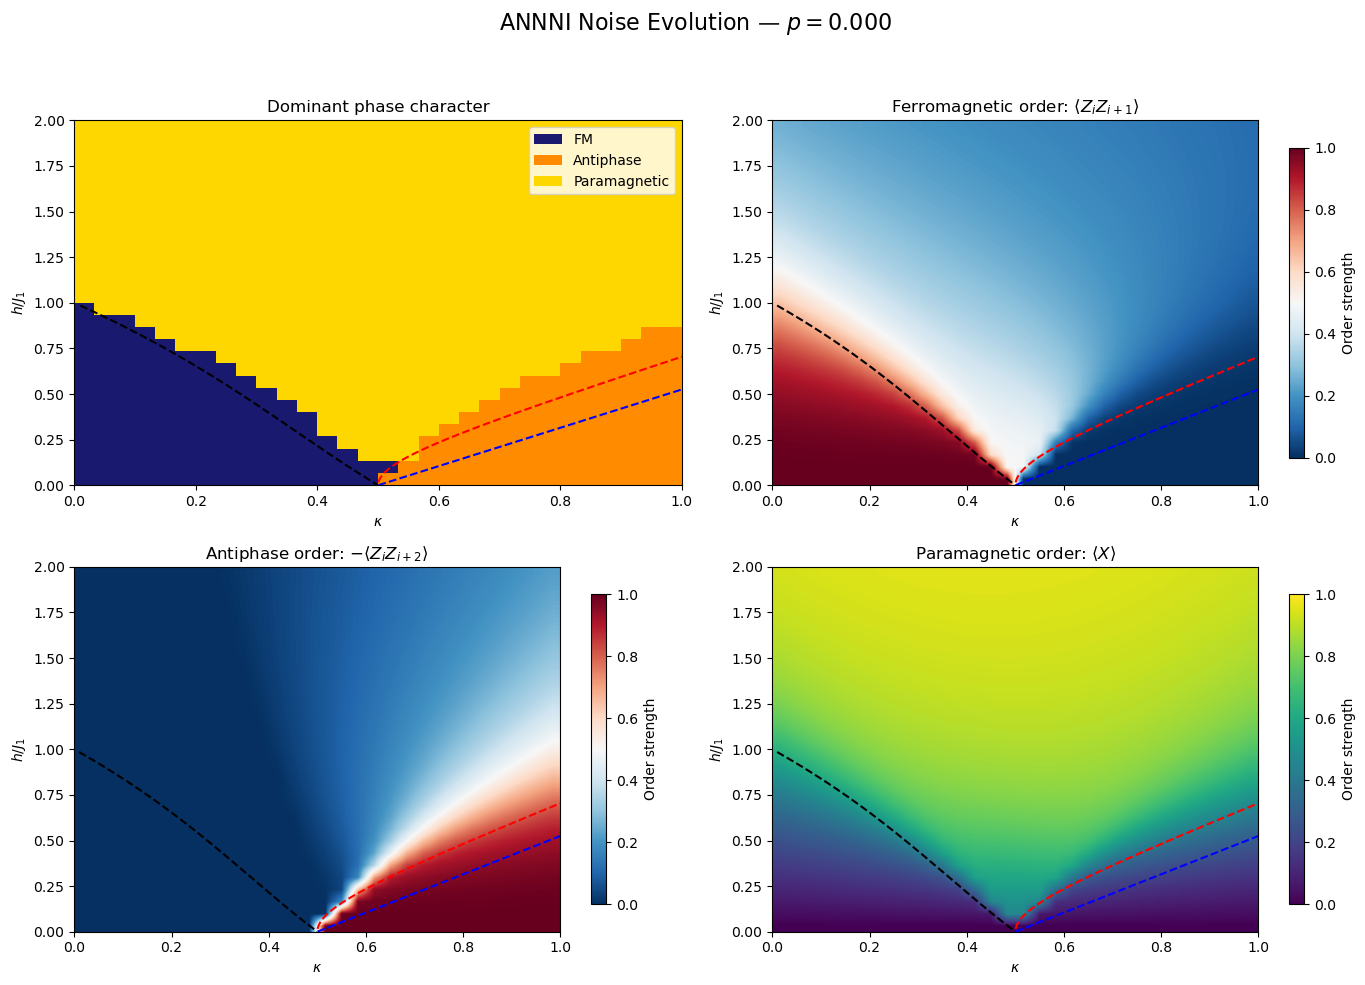

In [89]:
# ---------------------------------------------------------------------
# HIGH-QUALITY ANIMATED NOISE PHASE DIAGRAM
# ED observables + effective depolarizing noise
# ---------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display


# ---------------------------------------------------------------------
# Noise parameters
# ---------------------------------------------------------------------

noise_frames = np.linspace(
    0.0,
    0.05,
    26,
)

N_LAYERS_EFFECTIVE = VQE_LAYERS


# ---------------------------------------------------------------------
# Phase colors
# ---------------------------------------------------------------------

phase_colors = [
    "midnightblue",   # FM
    "darkorange",     # Antiphase
    "gold",            # Paramagnetic
]

phase_cmap = ListedColormap(
    phase_colors
)


# ---------------------------------------------------------------------
# Construct noisy observable maps
# ---------------------------------------------------------------------

def noisy_observable_maps(p):

    # Each qubit is targeted approximately twice per
    # variational layer: once by NN and once by NNN CNOTs.

    n_target_hits = (
        2 * N_LAYERS_EFFECTIVE
    )

    # One-qubit Pauli attenuation
    eta_1 = (
        1.0 - p
    ) ** n_target_hits

    # Two-qubit Pauli attenuation
    eta_2 = (
        1.0 - p
    ) ** (2 * n_target_hits)

    zz_nn = (
        ed_results["zz_nn"]
        * eta_2
    )

    zz_nnn = (
        ed_results["zz_nnn"]
        * eta_2
    )

    x_mag = (
        ed_results["mx"]
        * eta_1
    )

    # ------------------------------------------------------------
    # Order scores
    # ------------------------------------------------------------

    fm_score = np.maximum(
        zz_nn,
        0.0,
    )

    ap_score = np.maximum(
        -zz_nnn,
        0.0,
    )

    pm_score = np.maximum(
        x_mag,
        0.0,
    )

    scores = np.stack(
        [
            fm_score,
            ap_score,
            pm_score,
        ],
        axis=0,
    )

    phase_map = np.argmax(
        scores,
        axis=0,
    )

    return (
        phase_map,
        fm_score,
        ap_score,
        pm_score,
        zz_nn,
        zz_nnn,
        x_mag,
    )


# ---------------------------------------------------------------------
# Reference curves
# ---------------------------------------------------------------------

k_ref = np.linspace(
    0.01,
    1.0,
    1000,
)

# Ising
k_ising = k_ref[
    k_ref < 0.5
]

h_ising = (
    (1.0 - k_ising)
    / k_ising
    * (
        1.0
        - np.sqrt(
            (
                1.0
                - 3.0 * k_ising
                + 4.0 * k_ising**2
            )
            / (1.0 - k_ising)
        )
    )
)

# Upper KT
k_kt = k_ref[
    k_ref >= 0.5
]

h_kt = (
    1.05
    * np.sqrt(
        (k_kt - 0.5)
        * (k_kt - 0.1)
    )
)

# Lower BKT
h_bkt = (
    1.05
    * (k_kt - 0.5)
)


# ---------------------------------------------------------------------
# Create figure
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10),
)

ax_phase = axes[0, 0]
ax_fm = axes[0, 1]
ax_ap = axes[1, 0]
ax_pm = axes[1, 1]


extent = [
    kappas_ed[0],
    kappas_ed[-1],
    hs_ed[0],
    hs_ed[-1],
]


# ---------------------------------------------------------------------
# Initial frame
# ---------------------------------------------------------------------

(
    phase_map,
    fm_score,
    ap_score,
    pm_score,
    zz_nn,
    zz_nnn,
    x_mag,
) = noisy_observable_maps(
    0.0
)


im_phase = ax_phase.imshow(
    phase_map,
    origin="lower",
    aspect="auto",
    extent=extent,
    interpolation="nearest",
    cmap=phase_cmap,
    vmin=-0.5,
    vmax=2.5,
)

im_fm = ax_fm.imshow(
    fm_score,
    origin="lower",
    aspect="auto",
    extent=extent,
    interpolation="bilinear",
    cmap="RdBu_r",
    vmin=0,
    vmax=1,
)

im_ap = ax_ap.imshow(
    ap_score,
    origin="lower",
    aspect="auto",
    extent=extent,
    interpolation="bilinear",
    cmap="RdBu_r",
    vmin=0,
    vmax=1,
)

im_pm = ax_pm.imshow(
    pm_score,
    origin="lower",
    aspect="auto",
    extent=extent,
    interpolation="bilinear",
    cmap="viridis",
    vmin=0,
    vmax=1,
)


# ---------------------------------------------------------------------
# Titles
# ---------------------------------------------------------------------

ax_phase.set_title(
    "Dominant phase character"
)

ax_fm.set_title(
    r"Ferromagnetic order: $\langle Z_iZ_{i+1}\rangle$"
)

ax_ap.set_title(
    r"Antiphase order: $-\langle Z_iZ_{i+2}\rangle$"
)

ax_pm.set_title(
    r"Paramagnetic order: $\langle X\rangle$"
)


for ax in axes.flat:

    ax.set_xlabel(
        r"$\kappa$"
    )

    ax.set_ylabel(
        r"$h/J_1$"
    )


# ---------------------------------------------------------------------
# Analytical boundaries
# ---------------------------------------------------------------------

for ax in [
    ax_phase,
    ax_fm,
    ax_ap,
    ax_pm,
]:

    ax.plot(
        k_ising,
        h_ising,
        "k--",
        linewidth=1.5,
    )

    ax.plot(
        k_kt,
        h_kt,
        "r--",
        linewidth=1.5,
    )

    ax.plot(
        k_kt,
        h_bkt,
        "b--",
        linewidth=1.5,
    )


# ---------------------------------------------------------------------
# Phase legend
# ---------------------------------------------------------------------

from matplotlib.patches import Patch

phase_handles = [
    Patch(
        facecolor="midnightblue",
        label="FM",
    ),
    Patch(
        facecolor="darkorange",
        label="Antiphase",
    ),
    Patch(
        facecolor="gold",
        label="Paramagnetic",
    ),
]

ax_phase.legend(
    handles=phase_handles,
    loc="upper right",
)


# ---------------------------------------------------------------------
# Colorbars
# ---------------------------------------------------------------------

fig.colorbar(
    im_fm,
    ax=ax_fm,
    shrink=0.85,
    label="Order strength",
)

fig.colorbar(
    im_ap,
    ax=ax_ap,
    shrink=0.85,
    label="Order strength",
)

fig.colorbar(
    im_pm,
    ax=ax_pm,
    shrink=0.85,
    label="Order strength",
)


# ---------------------------------------------------------------------
# Main title
# ---------------------------------------------------------------------

suptitle = fig.suptitle(
    "ANNNI Noise Evolution — "
    r"$p=0.000$",
    fontsize=16,
)


# ---------------------------------------------------------------------
# Animation update
# ---------------------------------------------------------------------

def update(frame):

    p = float(
        noise_frames[frame]
    )

    (
        phase_map,
        fm_score,
        ap_score,
        pm_score,
        zz_nn,
        zz_nnn,
        x_mag,
    ) = noisy_observable_maps(
        p
    )

    im_phase.set_data(
        phase_map
    )

    im_fm.set_data(
        fm_score
    )

    im_ap.set_data(
        ap_score
    )

    im_pm.set_data(
        pm_score
    )

    suptitle.set_text(
        "ANNNI Noise Evolution — "
        rf"$p={p:.3f}$"
    )

    return (
        im_phase,
        im_fm,
        im_ap,
        im_pm,
    )


# ---------------------------------------------------------------------
# Create animation
# ---------------------------------------------------------------------

anim = FuncAnimation(
    fig,
    update,
    frames=len(noise_frames),
    interval=250,
    blit=False,
    repeat=True,
)

plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.95,
    ]
)

display(
    HTML(
        anim.to_jshtml()
    )
)

In [93]:
# ---------------------------------------------------------------------
# Representative-point noisy-energy table
# Direct QNode implementation
# ---------------------------------------------------------------------

noise_levels_table = [
    0.00,
    0.01,
    0.03,
    0.05,
]

test_points = [
    (0.20, 0.20, "ferromagnetic"),
    (0.80, 0.20, "antiphase"),
    (0.20, 1.60, "paramagnetic"),
]


# ---------------------------------------------------------------------
# Small noisy ANNNI energy circuit
# ---------------------------------------------------------------------

NOISY_ENERGY_DEV = qml.device(
    "default.mixed",
    wires=N_MAIN,
)


# ---------------------------------------------------------------------
# Correct noisy ANNNI energy QNode
# ---------------------------------------------------------------------

@qml.qnode(
    NOISY_ENERGY_DEV
)
def noisy_energy_qnode(
    kappa,
    h,
    theta,
    p,
    layers,
):

    n = N_MAIN

    # ------------------------------------------------------------
    # Initial state
    # ------------------------------------------------------------

    for i in range(n):

        qml.RY(
            theta,
            wires=i,
        )

    # ------------------------------------------------------------
    # Noisy entangling layers
    # ------------------------------------------------------------

    for layer in range(layers):

        # Nearest-neighbor CNOTs
        for i in range(n):

            target = (
                i + 1
            ) % n

            qml.CNOT(
                wires=[
                    i,
                    target,
                ]
            )

            if p > 0.0:

                qml.DepolarizingChannel(
                    p,
                    wires=target,
                )

        # Next-nearest-neighbor CNOTs
        for i in range(n):

            target = (
                i + 2
            ) % n

            qml.CNOT(
                wires=[
                    i,
                    target,
                ]
            )

            if p > 0.0:

                qml.DepolarizingChannel(
                    p,
                    wires=target,
                )

    # ------------------------------------------------------------
    # IMPORTANT:
    # Return the individual expectation values.
    # Do NOT multiply them by coefficients here.
    # ------------------------------------------------------------

    measurements = []

    # NN ZZ
    for i in range(n):

        j = (
            i + 1
        ) % n

        measurements.append(
            qml.expval(
                qml.PauliZ(i)
                @ qml.PauliZ(j)
            )
        )

    # NNN ZZ
    for i in range(n):

        j = (
            i + 2
        ) % n

        measurements.append(
            qml.expval(
                qml.PauliZ(i)
                @ qml.PauliZ(j)
            )
        )

    # X
    for i in range(n):

        measurements.append(
            qml.expval(
                qml.PauliX(i)
            )
        )

    return tuple(
        measurements
    )


# ---------------------------------------------------------------------
# Energy wrapper
# ---------------------------------------------------------------------

# ---------------------------------------------------------------------
# Convert noisy measurements into ANNNI energy
# ---------------------------------------------------------------------

def direct_noisy_energy(
    n_qubits,
    kappa,
    h,
    theta=0.4,
    p=0.0,
    layers=2,
):

    if n_qubits != N_MAIN:

        raise ValueError(
            f"This QNode uses N_MAIN={N_MAIN}. "
            f"Received n_qubits={n_qubits}."
        )

    values = noisy_energy_qnode(
        float(kappa),
        float(h),
        float(theta),
        float(p),
        int(layers),
    )

    values = np.asarray(
        values,
        dtype=float,
    )

    n = n_qubits

    # ------------------------------------------------------------
    # Extract measurements
    # ------------------------------------------------------------

    zz_nn = values[
        0:n
    ]

    zz_nnn = values[
        n:2*n
    ]

    x_values = values[
        2*n:3*n
    ]

    # ------------------------------------------------------------
    # Construct ANNNI energy
    #
    # H =
    #   - sum ZZ_nn
    #   + kappa sum ZZ_nnn
    #   - h sum X
    # ------------------------------------------------------------

    energy = (

        -np.sum(
            zz_nn
        )

        + float(kappa)
        * np.sum(
            zz_nnn
        )

        - float(h)
        * np.sum(
            x_values
        )
    )

    return float(
        energy
    )


# ---------------------------------------------------------------------
# Generate table
# ---------------------------------------------------------------------

print()
print("=" * 82)
print(
    f"Representative-point noisy energy table "
    f"(N={N_MAIN})"
)
print("=" * 82)

header = (
    f"{'phase':15s}"
    f"{'(κ, h)':>12s}"
    + "  "
    + "  ".join(
        f"p={p:.2f}"
        for p in noise_levels_table
    )
)

print(header)
print("-" * len(header))


for kappa, h, label in test_points:

    energies = []

    for p in noise_levels_table:

        energy = direct_noisy_energy(
            n_qubits=N_MAIN,
            kappa=float(kappa),
            h=float(h),
            theta=0.4,
            p=float(p),
            layers=2,
        )

        energies.append(
            energy
        )

    print(
        f"{label:15s}"
        f"({kappa:.1f}, {h:.1f})"
        + "  "
        + "  ".join(
            f"{e:+8.4f}"
            for e in energies
        )
    )


print("=" * 82)


Representative-point noisy energy table (N=8)
phase                (κ, h)  p=0.00  p=0.01  p=0.03  p=0.05
-----------------------------------------------------------
ferromagnetic  (0.2, 0.2)   -4.4728   -3.5140   -2.1483   -1.2957
antiphase      (0.8, 0.2)   -0.9655   -0.6452   -0.2402   -0.0372
paramagnetic   (0.2, 1.6)   -5.2224   -4.1499   -2.6038   -1.6198


Increasing depolarizing noise progressively suppresses the NN correlation, reducing the contrast between the ordered and high-field regimes.

Calculating exact ED line cut: kappa=0.3, N=8
Exact ED line cut complete.

Estimated finite-size crossover:
  kappa = 0.300
  h/J1  ≈ 0.460


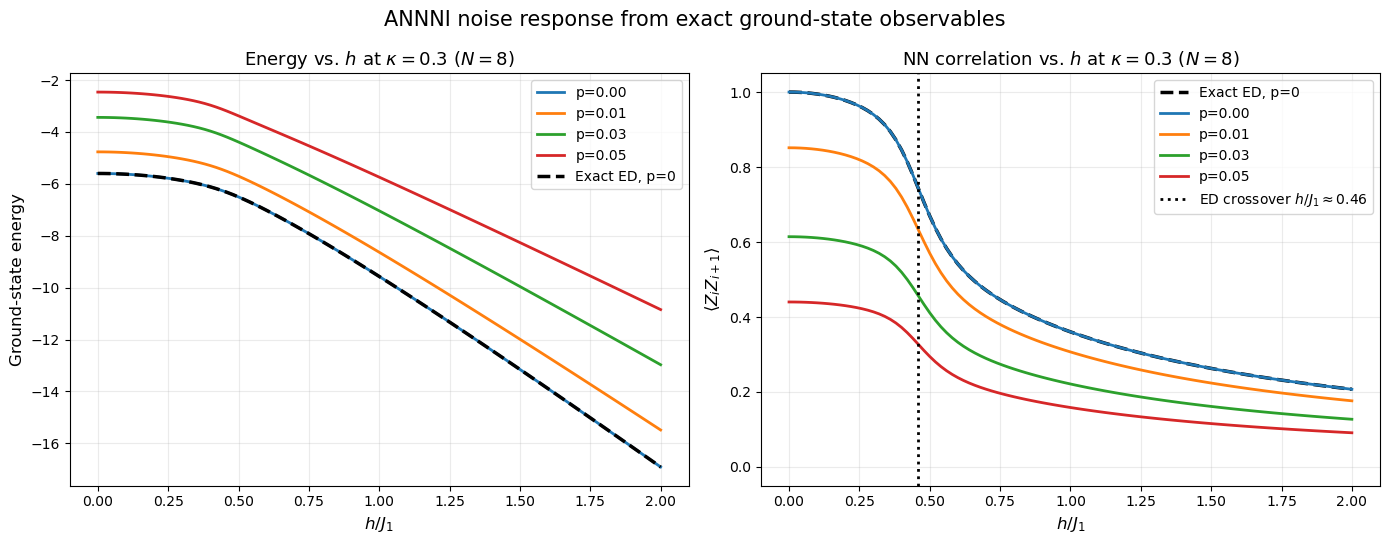

In [ ]:
# ---------------------------------------------------------------------
# Improved noise line-cut:
# ED ground state + effective depolarizing noise
# ---------------------------------------------------------------------



# =====================================================================
# 1. Parameters
# =====================================================================

KAPPA_LINE = 0.30
N_LINE = N_MAIN

H_VALUES = np.linspace(
    0.0,
    2.0,
    101,
)

NOISE_LEVELS = [
    0.00,
    0.01,
    0.03,
    0.05,
]

# Effective number of noisy gate encounters.
# Each VQE layer contains:
#   1 NN entangling layer
#   1 NNN entangling layer
N_EFFECTIVE = 2 * VQE_LAYERS


# =====================================================================
# 2. Storage
# =====================================================================

energy_clean = np.zeros(
    len(H_VALUES)
)

zz_clean = np.zeros(
    len(H_VALUES)
)

zz_nnn_clean = np.zeros(
    len(H_VALUES)
)

mx_clean = np.zeros(
    len(H_VALUES)
)


energy_noise = {
    p: np.zeros(
        len(H_VALUES)
    )
    for p in NOISE_LEVELS
}

zz_noise = {
    p: np.zeros(
        len(H_VALUES)
    )
    for p in NOISE_LEVELS
}

mx_noise = {
    p: np.zeros(
        len(H_VALUES)
    )
    for p in NOISE_LEVELS
}


# =====================================================================
# 3. Exact ED line cut
# =====================================================================

print(
    f"Calculating exact ED line cut:"
    f" kappa={KAPPA_LINE}, N={N_LINE}"
)

for ih, h in enumerate(H_VALUES):

    obs = exact_point_extended(
        N_LINE,
        KAPPA_LINE,
        float(h),
    )

    # Exact ground-state energy
    energy_clean[ih] = (
        obs["energy"]
    )

    # NN correlation
    zz_clean[ih] = (
        obs["zz_nn"]
    )

    # NNN correlation
    zz_nnn_clean[ih] = (
        obs["zz_nnn"]
    )

    # Transverse magnetization
    mx_clean[ih] = abs(
        obs["mx"]
    )


print(
    "Exact ED line cut complete."
)


# =====================================================================
# 4. Estimate finite-size FM -> high-field crossover
# =====================================================================
#
# We locate the crossover from the maximum magnitude of
# d<Zi Zi+1>/dh.
#
# This is a finite-size crossover estimate, NOT a thermodynamic
# critical point.
# =====================================================================

dzz_dh = np.gradient(
    zz_clean,
    H_VALUES,
)

transition_index = np.argmin(
    dzz_dh
)

h_transition = H_VALUES[
    transition_index
]

print()
print(
    "Estimated finite-size crossover:"
)

print(
    f"  kappa = {KAPPA_LINE:.3f}"
)

print(
    f"  h/J1  ≈ {h_transition:.3f}"
)


# =====================================================================
# 5. Effective depolarizing-noise model
# =====================================================================

for p in NOISE_LEVELS:

    # ------------------------------------------------------------
    # Single-qubit observable attenuation
    # ------------------------------------------------------------

    eta_1 = (
        1.0 - p
    ) ** N_EFFECTIVE

    # ------------------------------------------------------------
    # Two-qubit observable attenuation
    # ------------------------------------------------------------

    eta_2 = (
        1.0 - p
    ) ** (2 * N_EFFECTIVE)

    # ------------------------------------------------------------
    # NN correlation
    # ------------------------------------------------------------

    zz_noise[p] = (
        zz_clean
        * eta_2
    )

    # ------------------------------------------------------------
    # X magnetization
    # ------------------------------------------------------------

    mx_noise[p] = (
        mx_clean
        * eta_1
    )

    # ------------------------------------------------------------
    # Energy
    #
    # E =
    # - sum <Zi Zi+1>
    # + kappa sum <Zi Zi+2>
    # - h sum <Xi>
    # ------------------------------------------------------------

    zz_nn_p = (
        zz_clean
        * eta_2
    )

    zz_nnn_p = (
        zz_nnn_clean
        * eta_2
    )

    mx_p = (
        mx_clean
        * eta_1
    )

    energy_noise[p] = (
        -N_LINE * zz_nn_p
        + KAPPA_LINE
        * N_LINE
        * zz_nnn_p
        - H_VALUES
        * N_LINE
        * mx_p
    )


# =====================================================================
# 6. Plot
# =====================================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.5),
)


# =====================================================================
# LEFT PANEL: ENERGY
# =====================================================================

ax = axes[0]

for p in NOISE_LEVELS:

    ax.plot(
        H_VALUES,
        energy_noise[p],
        linewidth=2,
        label=f"p={p:.2f}",
    )


# Exact ED ground-state energy
ax.plot(
    H_VALUES,
    energy_clean,
    "k--",
    linewidth=2.5,
    label="Exact ED, p=0",
)


ax.set_xlabel(
    r"$h/J_1$",
    fontsize=12,
)

ax.set_ylabel(
    "Ground-state energy",
    fontsize=12,
)

ax.set_title(
    rf"Energy vs. $h$ at "
    rf"$\kappa={KAPPA_LINE}$ "
    rf"($N={N_LINE}$)",
    fontsize=13,
)

ax.grid(
    alpha=0.25
)

ax.legend()


# =====================================================================
# RIGHT PANEL: NN CORRELATION
# =====================================================================

ax = axes[1]


# ------------------------------------------------------------
# Exact ED
# ------------------------------------------------------------

ax.plot(
    H_VALUES,
    zz_clean,
    "k--",
    linewidth=2.5,
    label="Exact ED, p=0",
)


# ------------------------------------------------------------
# Noisy curves
# ------------------------------------------------------------

for p in NOISE_LEVELS:

    ax.plot(
        H_VALUES,
        zz_noise[p],
        linewidth=2,
        label=f"p={p:.2f}",
    )


# ------------------------------------------------------------
# Finite-size crossover
# ------------------------------------------------------------

ax.axvline(
    h_transition,
    color="black",
    linestyle=":",
    linewidth=2,
    label=(
        rf"ED crossover "
        rf"$h/J_1\approx{h_transition:.2f}$"
    ),
)


ax.set_xlabel(
    r"$h/J_1$",
    fontsize=12,
)

ax.set_ylabel(
    r"$\langle Z_i Z_{i+1}\rangle$",
    fontsize=12,
)

ax.set_title(
    rf"NN correlation vs. $h$ at "
    rf"$\kappa={KAPPA_LINE}$ "
    rf"($N={N_LINE}$)",
    fontsize=13,
)

ax.set_ylim(
    -0.05,
    1.05,
)

ax.grid(
    alpha=0.25
)

ax.legend()


# =====================================================================
# 7. Overall title
# =====================================================================

fig.suptitle(
    "ANNNI noise response from exact ground-state observables",
    fontsize=15,
)


plt.tight_layout()

plt.show()